# Intro to Numpy and PageRank

## TL;DR

PageRank computation cost:

 - using Python lists: **73 s.**
 - using NumPy arrays: **0.69 s.**

**NumPy can be more 100 times faster.**

## PageRank Recap

**Idea:** let's assume every node in a graph has initially the same importance, and this is propagated and split among its neighbours. Repeat this propagation until convergence.

**Problems:** Does it converge?

 - Only if the original graph is **irreducible** (any state is reachable from any other state) and **aperiodic** (no “cycles” of fixed length)
 - The Web Graph does not satisfy this criteria (it has **dead ends** and **cycles**)


**Solution** (leading to the so called **Google Matrix**): 


$$\pi^{t+1} = \beta M\pi^{t} + (1-\beta) 1/n
\quad\quad \textsf{with}\quad\quad 
M[i,j] =  \begin{cases} \frac{ 1 }{o(j)} & \textsf{if}\ j\rightarrow i \\
1/n & \textsf{if}\ o(j)=0 \\
0  & \textsf{otherwise}
\end{cases}
$$

 - with probability $\beta$ we follow $M$, with probability $(1-\beta)$ we jump to a random node (**teleportation**)
 - **dead ends removal** by "linking" them to every other nodes

The PageRank $\pi$ is the stable state distribution of the above:

 - i.e., such that $\pi^{t+1}=\pi^{t}$
 - this usually happens after less than 50 iterations



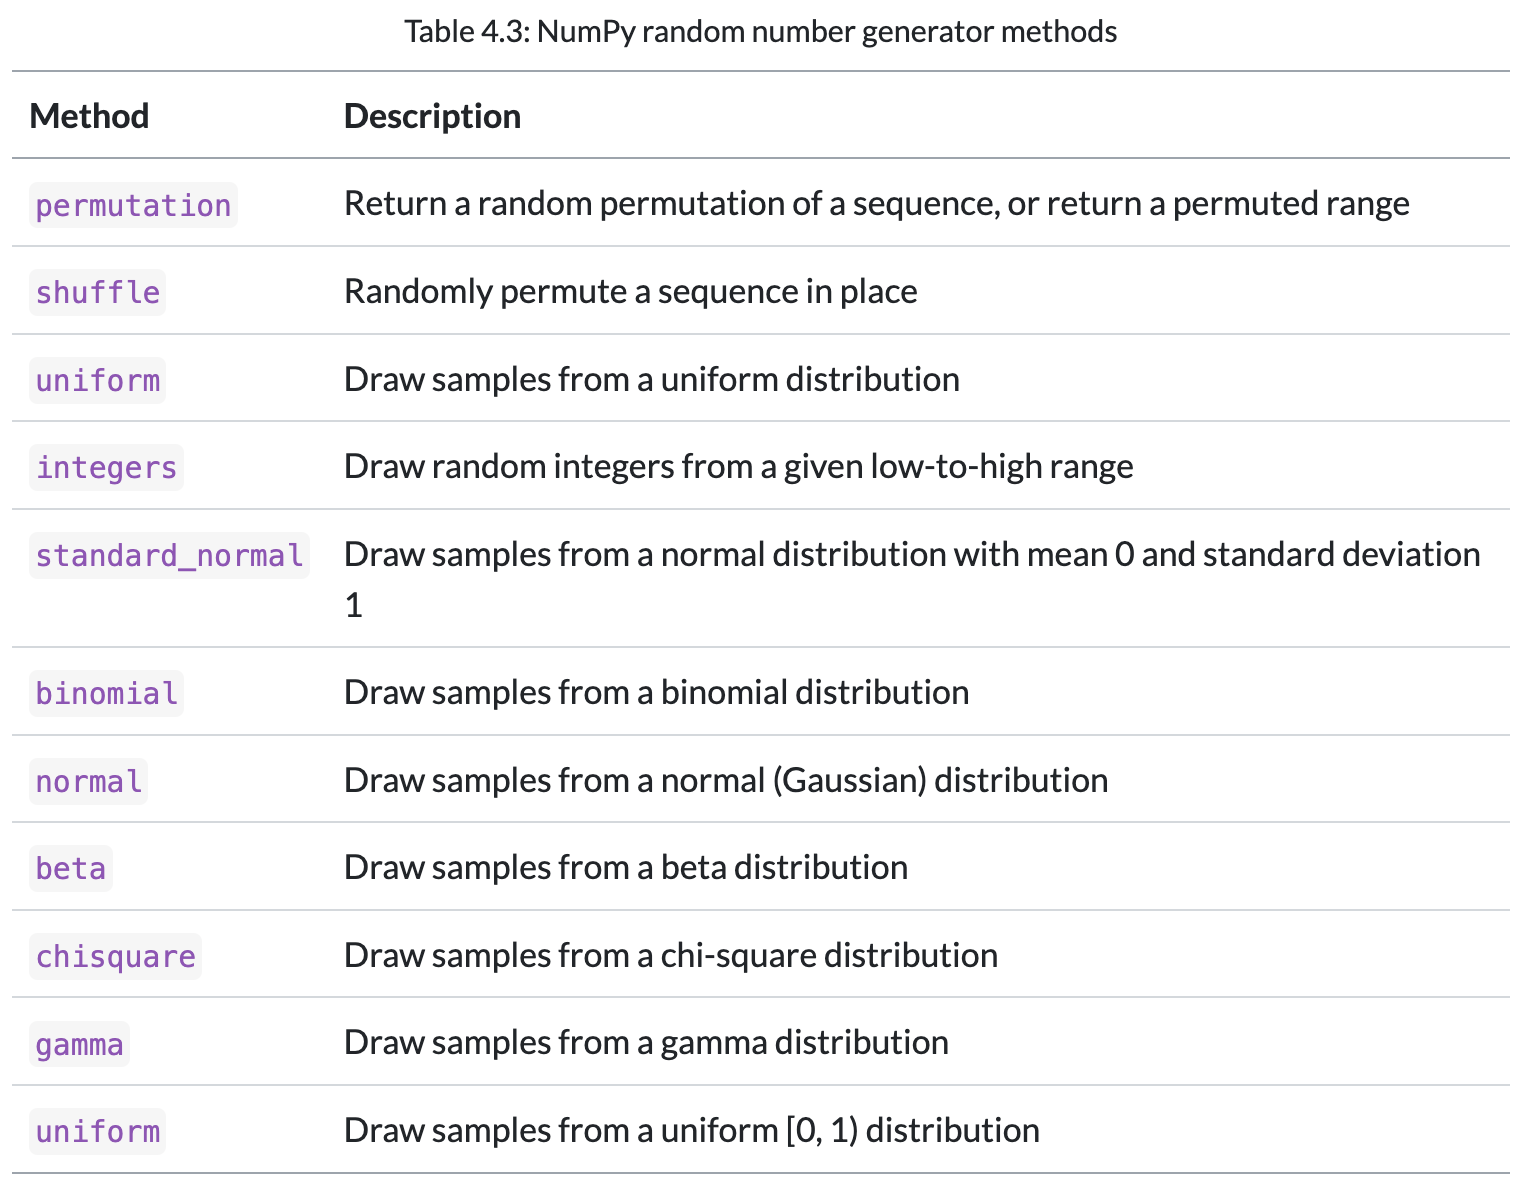

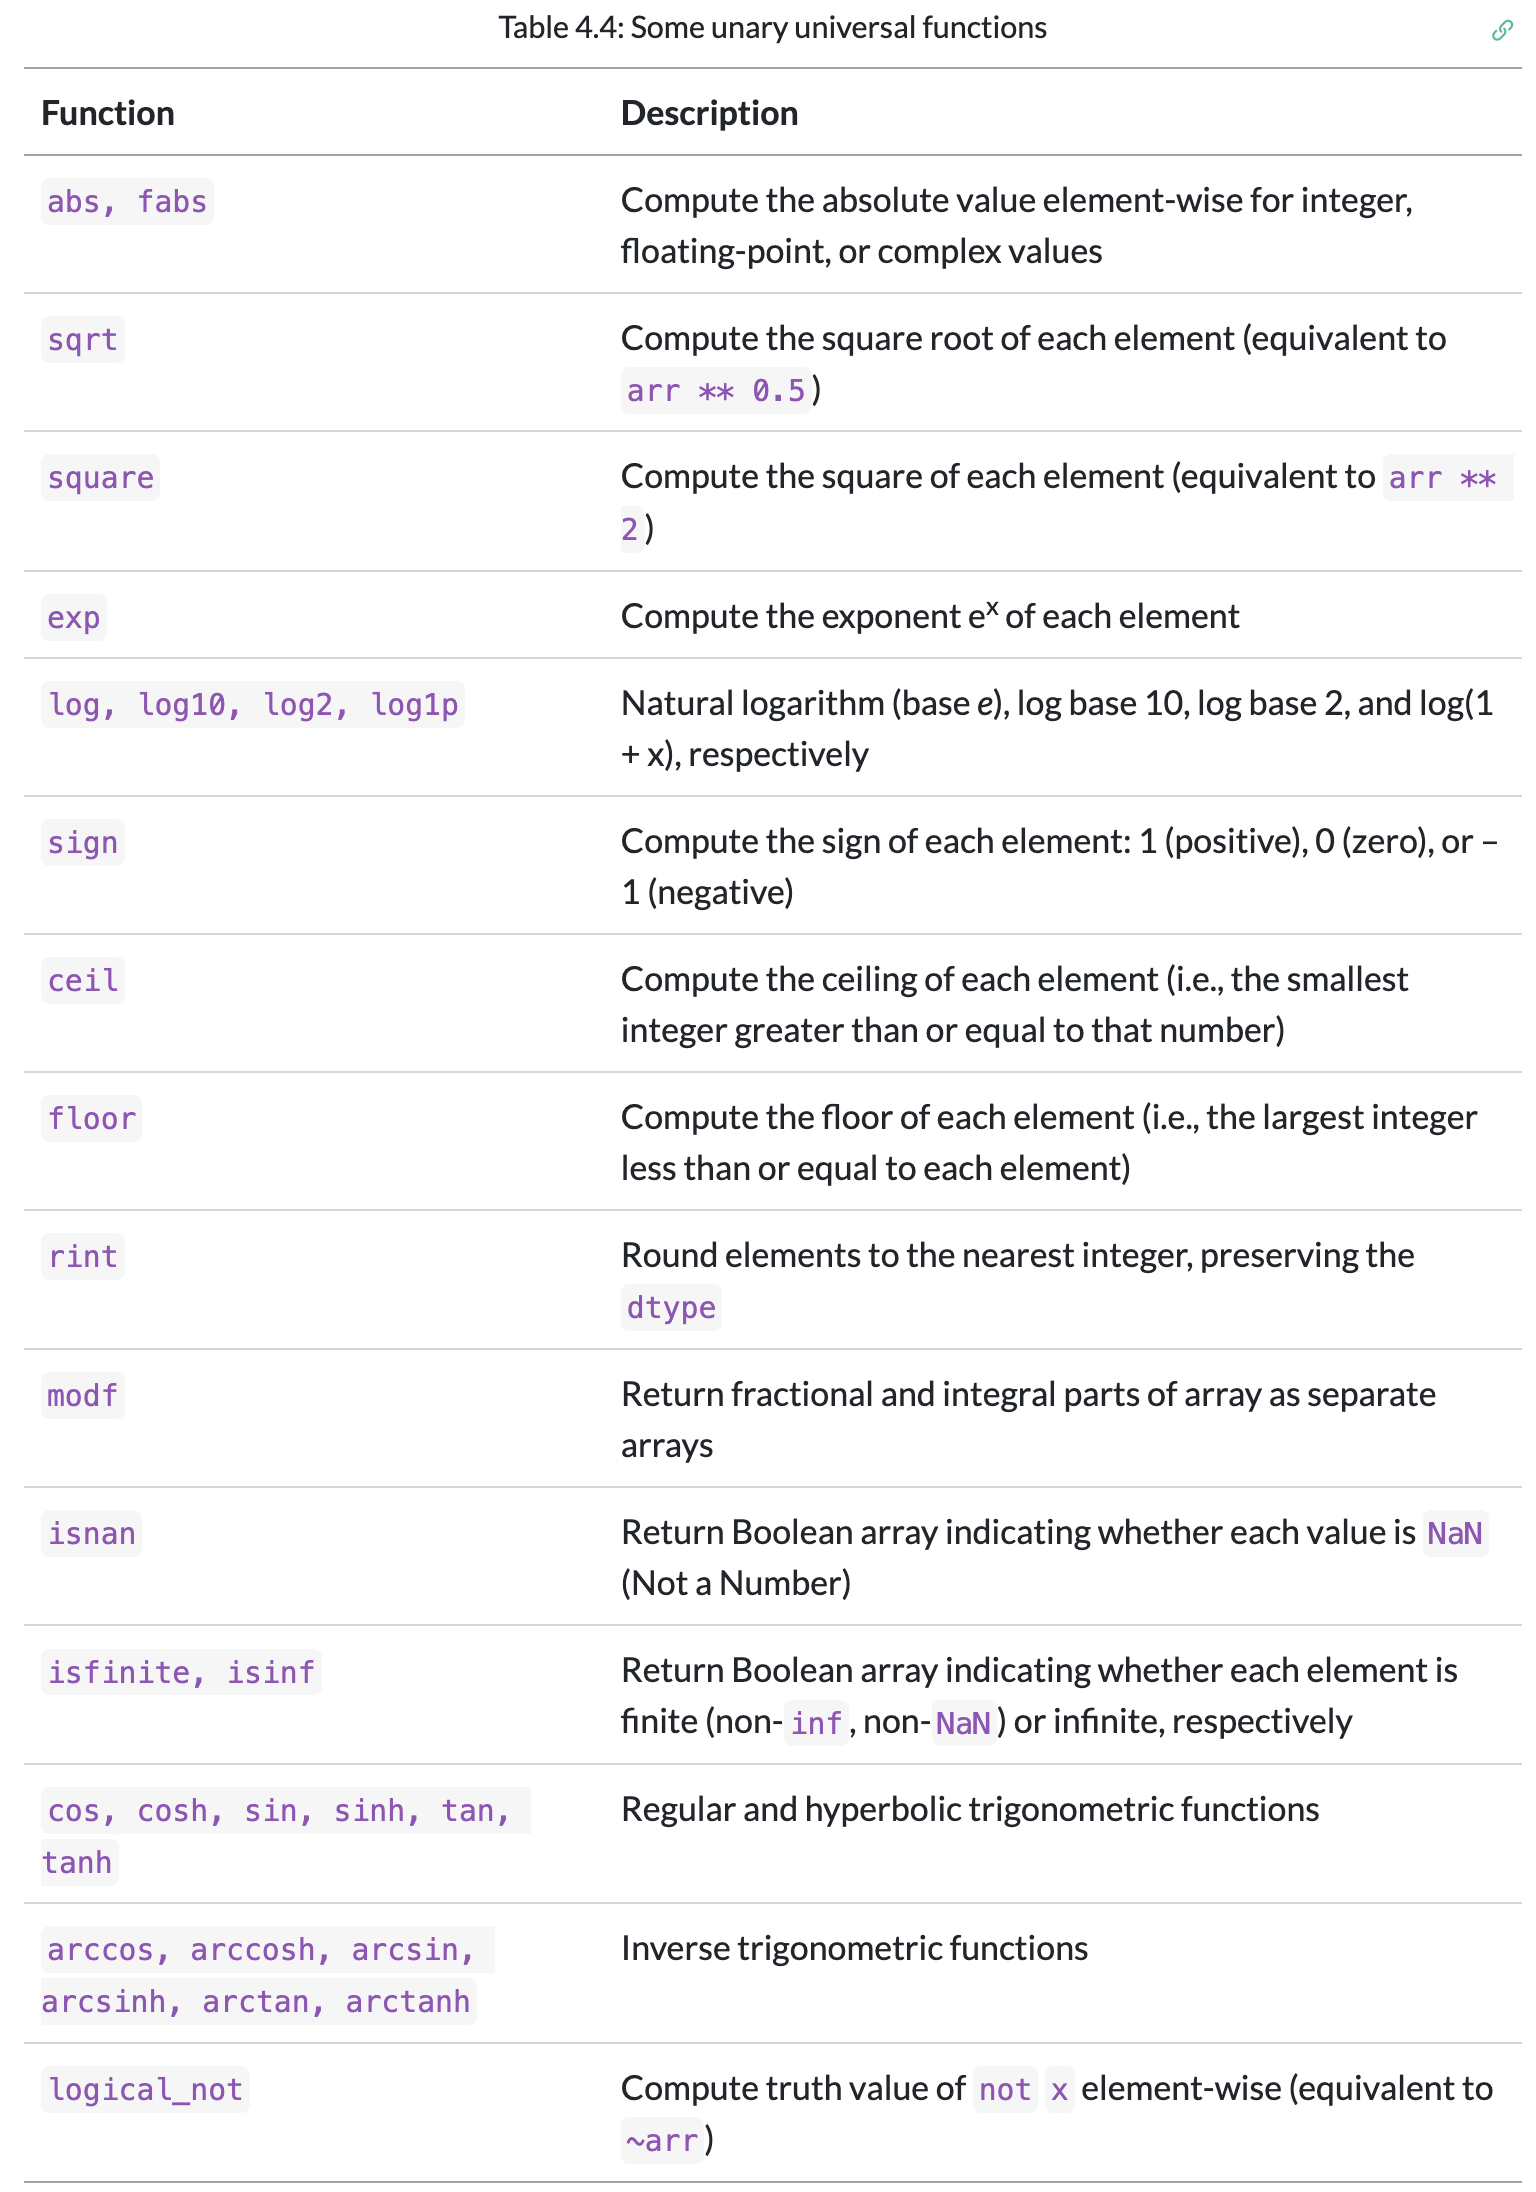

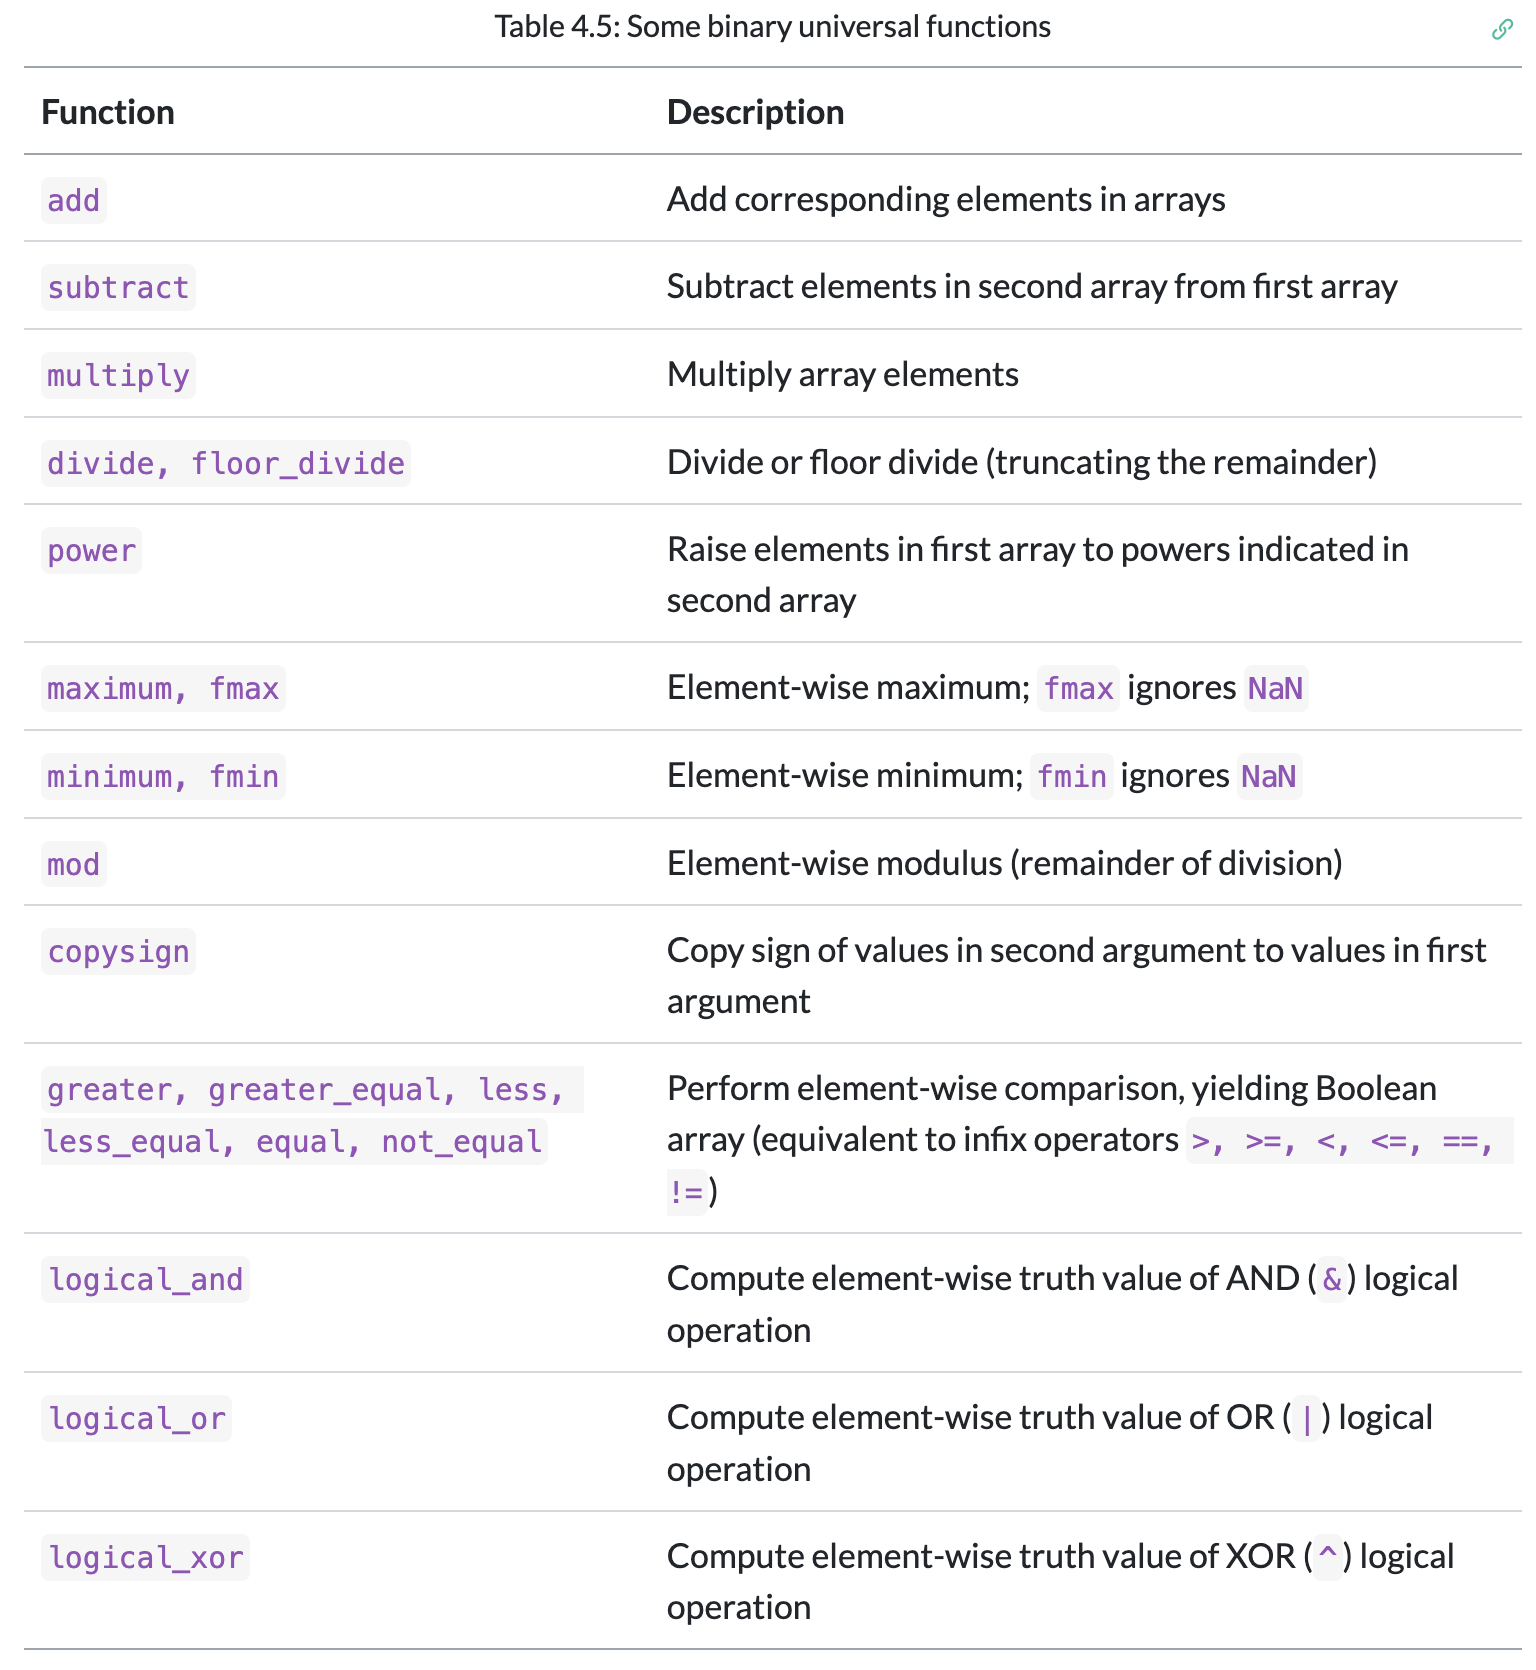

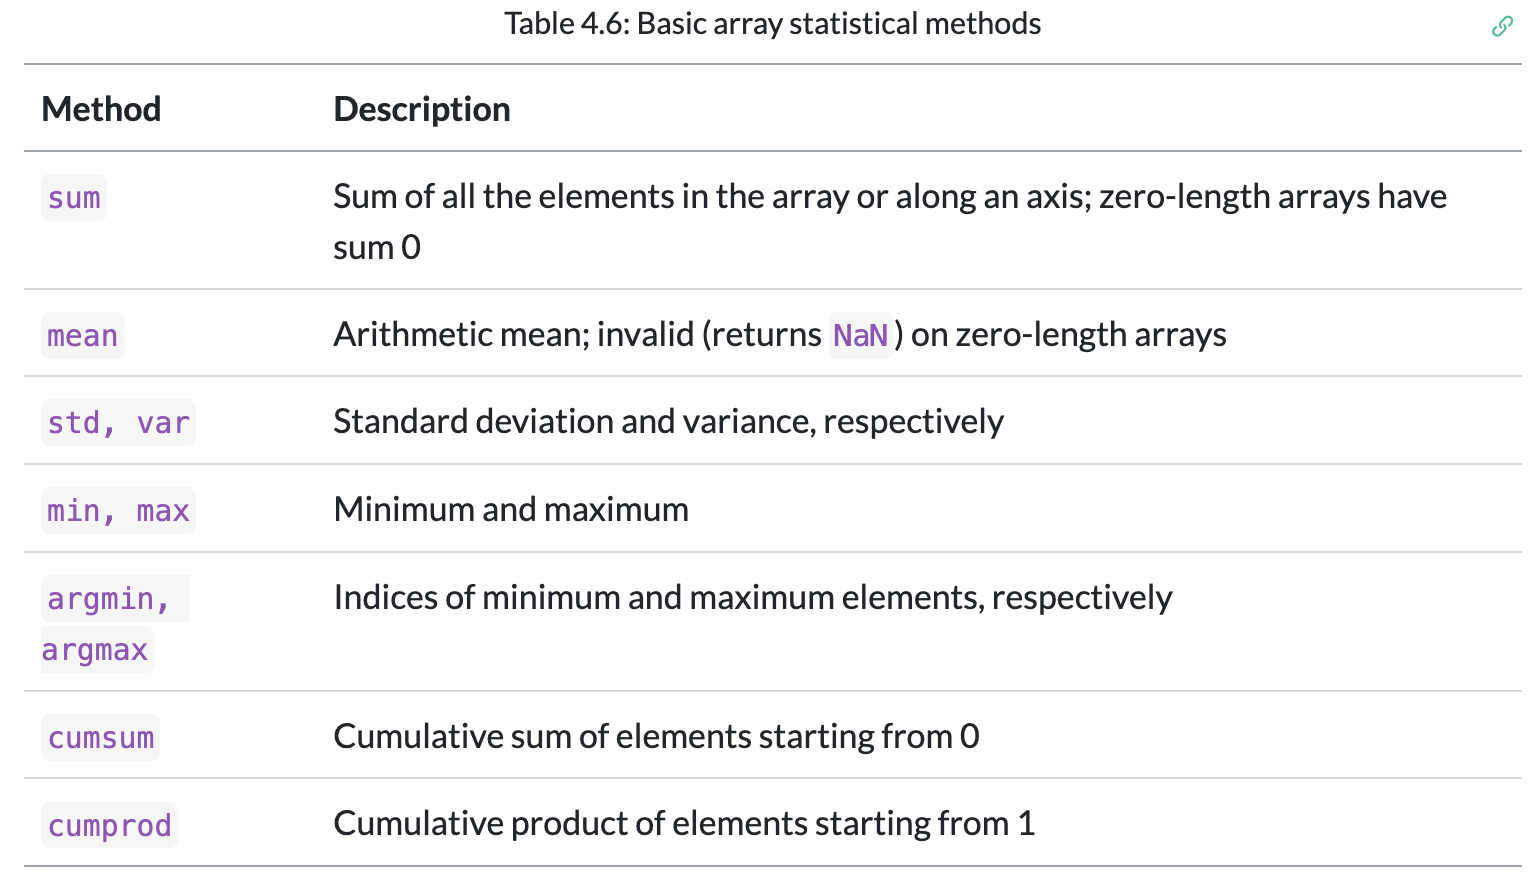

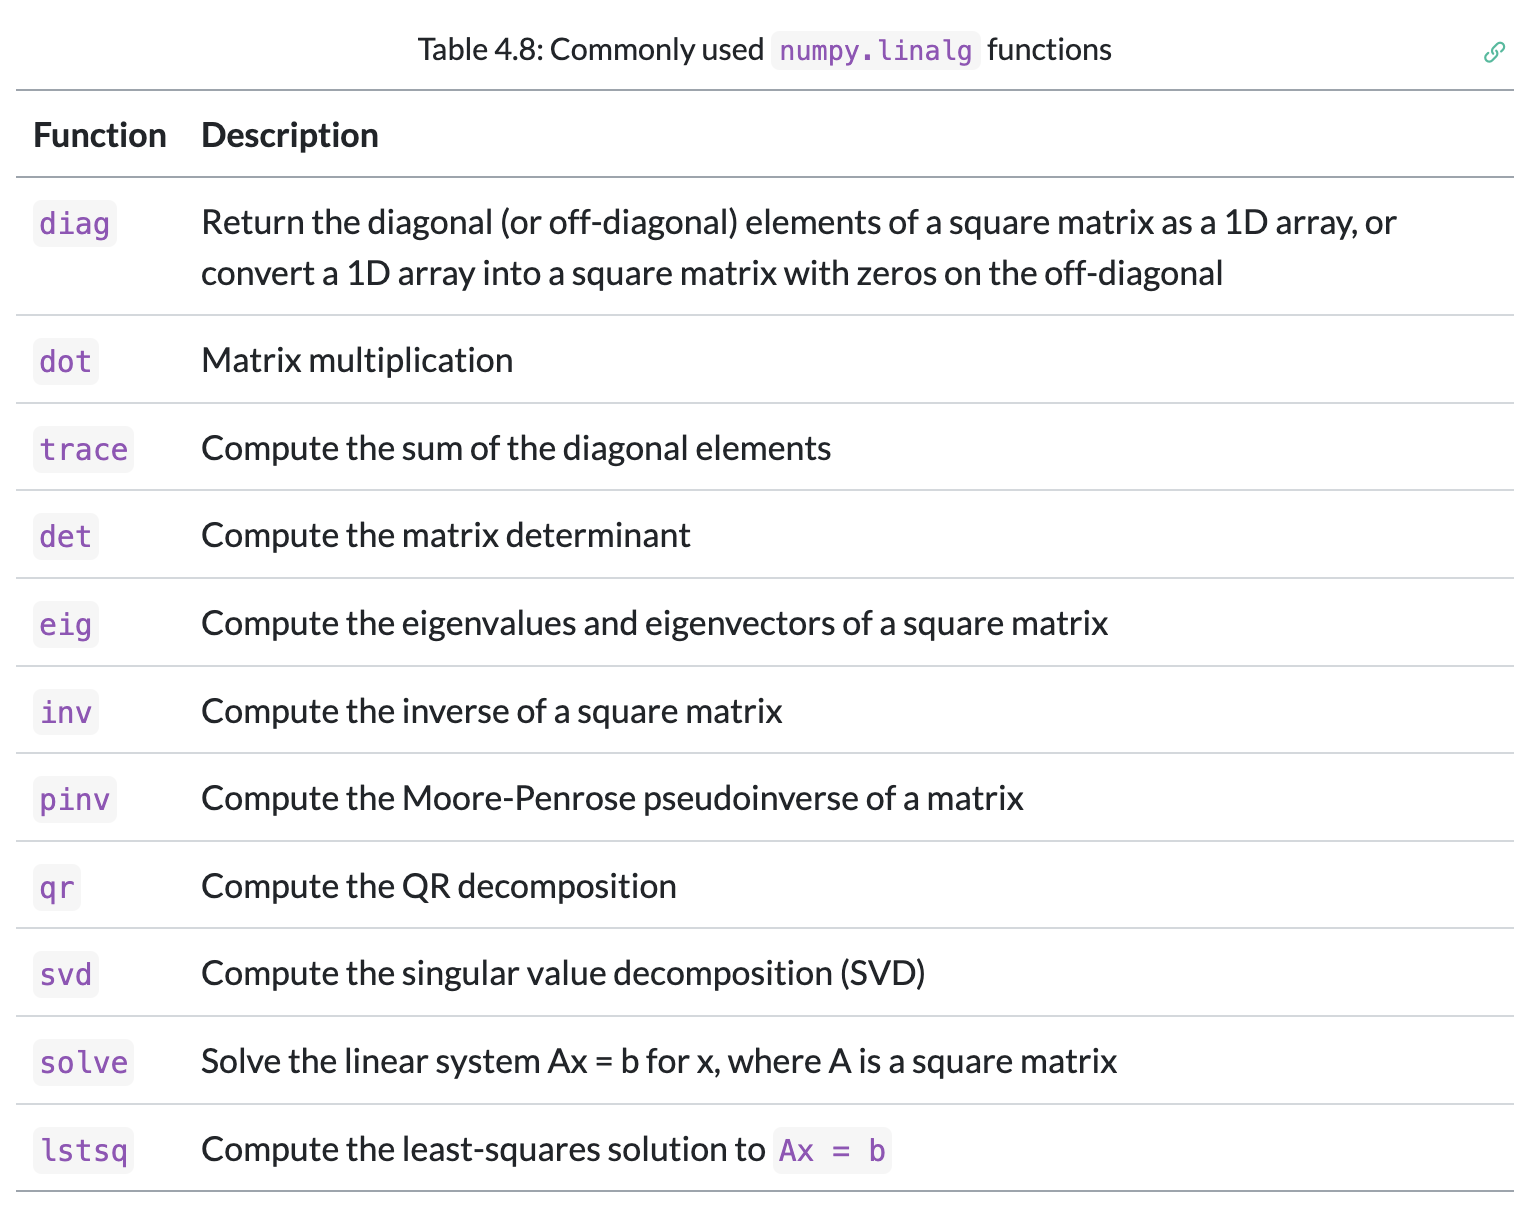

## Multi-Threading

Numpy functions are highly optimized, including SIMD instructions and multi-threading.

This provides a great boost, but not as much as C/C++ where one can optimize the whole computation.

Consider the simple Matrix Multiplication.

Numpy implementations do not expose their details, we can enforce a fragment of code to use a limited number of threads with `threadpoolctl`.

We use `time.perf_counter()` to measure running time accurately

## PageRank dataset

We will use the The Marvel Universe Social Network.

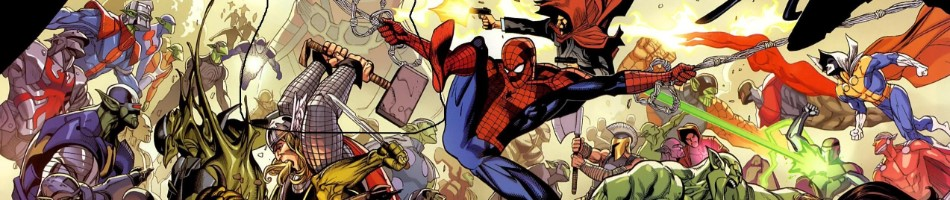

The data contains the network of heroes which appear together in the comics. That is one edge hero1 -> hero2 for each comic they appear in together.

https://www.kaggle.com/datasets/csanhueza/the-marvel-universe-social-network/data


In [ ]:
RAW_EDGES = "hero-network.csv"

import csv
import numpy as np

def read_edges_with_counts_csv(filename, has_header=True):
    """
    Reads a CSV file containing edges and counts duplicates.

    Assumes first two columns are:
        source, target

    Edges are "harmonized" so as source < target

    Parameters
    ----------
    filename : str
    has_header : bool
        If True, skips first row.

    Returns
    -------
    list of (source, target, count)
    """

    edge_counts = {}

    with open(filename, newline='', encoding="utf-8") as f:
        reader = csv.reader(f)

        if has_header:
            next(reader, None)  # skip header

        for row in reader:
            source = row[0].strip()
            target = row[1].strip()

            if source < target:
                key = (source, target)
            else:
                key = (target, source)

            if key in edge_counts:
                edge_counts[key] += 1
            else:
                edge_counts[key] = 1

    return [(src, tgt, count) for (src, tgt), count in edge_counts.items()]

def build_adjacency_Matrix(edges, is_undirected=True):
    """
    Build dense adjacency matrix A with convention:
        A[i, j] = 1 if j -> i  (optionally one could use weights)
    For co-appearance (undirected), we add both directions with same weight.
    """
    names = sorted({u for u, _, _ in edges} | {v for _, v, _ in edges})
    idx = {name: i for i, name in enumerate(names)}
    n = len(names)
    A = np.zeros((n, n), dtype=np.float64)

    for src, tgt, count in edges:
        src_id = idx[src]
        tgt_id = idx[tgt]
        A[tgt_id, src_id] = 1  # src -> tgt
        if is_undirected:   # undirected -> two directed edges
            A[src_id, tgt_id] = 1  # tgt -> src
    
    return A, names


In [ ]:
edges = read_edges_with_counts_csv(RAW_EDGES)
A, names = build_adjacency_Matrix(edges) 

In [ ]:
A.shape, len(names)

((6421, 6421), 6421)

In [ ]:
names[:10]

['24-HOUR MAN/EMMANUEL',
 '3-D MAN/CHARLES CHAN',
 '4-D MAN/MERCURIO',
 '8-BALL/',
 'A',
 "A'YIN",
 'ABBOTT, JACK',
 'ABCISSA',
 'ABEL',
 'ABOMINATION | MUTANT']

## PageRank Numpy implementation

In [ ]:
import numpy as np

def build_transition_matrix(A, is_sparse=False):
    """
    Build the PageRank transition matrix M from adjacency matrix A.

    Convention:
        A[i][j] = 1 if node j links to node i (j -> i).
        Columns are sources; rows are destinations.

    Returns
    -------
    M : ndarray (n, n)
        Column-stochastic transition matrix where M[i][j] = Prob(move from j to i).
        Each column sums to 1.
        Dangling columns become uniform (1/n).
    """
    if is_sparse:
        M = sparse.csr_matrix(A, dtype=np.float64) 
    else:
        # make it numpy array, and make sure it is copied
        M = np.asarray(A, copy=True, dtype=np.float64)
    
    n = M.shape[0]
    outdeg = np.asarray( M.sum(axis=0) ).ravel()

    # non-dangling columns: normalize each column by its outdegree
    non_dangling = outdeg > 0
    M[:, non_dangling] = M[:, non_dangling] / outdeg[non_dangling]

    # dangling columns: uniform distribution
    dangling = outdeg == 0
    if np.any(dangling):
        M[:, dangling] = 1.0 / n

    return M


def compute_pagerank(A, alpha=0.85, tol=1e-6, max_iter=100, is_sparse=False, verbose=False):
    """
    Compute PageRank

    Parameters
    ----------
    A : array_like (n, n)
        Dense adjacency with A[i, j] > 0 iff j -> i.
    alpha : float
        Damping factor.
    tol : float
        Convergence tolerance on L1 difference.
    max_iter : int
        Maximum iterations.
    verbose : bool
        Print L1 diff each iteration if True.

    Returns
    -------
    r : ndarray (n,)
        PageRank vector (sums to 1).
    iters : int
        Iterations performed.
    diff : float
        L1 difference from previous iteration.
    """
    M = build_transition_matrix(A, is_sparse)
    n = M.shape[0]

    # initial ranks
    pagerank = np.full(n, 1.0 / n, dtype=np.float64)

    for it in range(1, max_iter + 1):
        pagerank_next = alpha * (M @ pagerank) + (1.0 - alpha) * 1.0 / n
        pagerank_next = pagerank_next / pagerank_next.sum()  # normalize

        diff = np.abs(pagerank_next - pagerank).sum()  # L1
        if verbose:
            print(f"iter {it}: L1 diff = {diff:.3e}")

        if diff < tol:
            return pagerank_next, it, diff

        pagerank = pagerank_next

    return pagerank_next, max_iter, diff

## Compare Running times

In [51]:
import time
import numpy as np
from pympler import asizeof  # memory footprint
from scipy import sparse     # sparse matrix support

In [ ]:
edges = read_edges_with_counts_csv(RAW_EDGES)
A, names = build_adjacency_Matrix(edges) 

### Numpy Dense Matrix

In [ ]:
start = time.perf_counter()

r_dense, iters, d = compute_pagerank(A, alpha=0.85, tol=1e-9, max_iter=200, is_sparse=False, verbose=False)

elapsed = time.perf_counter()-start

footprint = asizeof.asizeof( build_transition_matrix(A, is_sparse=False) )

print (f"Elapsed time: {elapsed:.2f} sec.s")
print(f"Memory footprint {footprint/10**6:.2f} MB.")

print("PageRank:", r_dense)
print("iters:", iters)
print("sum:", r_dense.sum())

Elapsed time: 0.89 sec.s
Memory footprint 329.83 MB.
PageRank: [6.29994719e-05 2.85812118e-04 1.81257318e-04 ... 2.24083739e-04
 2.74567214e-04 9.78196648e-05]
iters: 64
sum: 1.0000000000000002


### Numpy Sparse Matrix

In [ ]:
start = time.perf_counter()
     
r_sparse, iters, d = compute_pagerank(A, alpha=0.85, tol=1e-9, max_iter=200, is_sparse=True, verbose=False)

elapsed = time.perf_counter()-start

footprint = asizeof.asizeof( build_transition_matrix(A, is_sparse=True) )

print (f"Elapsed time: {elapsed:.2f} sec.s")
print(f"Memory footprint {footprint/10**6:.2f} MB.")

print("PageRank:", r_sparse)
print("iters:", iters)
print("sum:", r_sparse.sum())

Elapsed time: 0.67 sec.s
Memory footprint 8.05 MB.
PageRank: [6.29994719e-05 2.85812118e-04 1.81257318e-04 ... 2.24083739e-04
 2.74567214e-04 9.78196648e-05]
iters: 64
sum: 1.0
